# Theory calculator Magnetic accelerator

## All Constants + Parameters

In [16]:
import math
mu0 =1.25663706127e-6
V = math.pi*0.035/2*0.035/2*0.004 #volume of cylinder
Br_cube = 1.306
Br_cyl = 1.215
mag_amt = 4 # amount of magnets along y
angle = 90-83
s_cube = 0.01 #side of cube
d_cu_cu = 0.011 #distance between cubes
d = -0.04 #x distance cyl - edge of plate
start_x, start_y = d - 0.0118 ,0 #place of the wheel in the rilles in my setup relative to the starting magnet, first row
mag_diam = 0.035 #diameter of magnet
M_cyl = Br_cyl / mu0
M_vehicle = 0.07125+0.027
rolling_start_y =0.025
rolling_end_y = 0.225
half_length_cube = 0.005 #half length of cube
plate_factor = 1.14

## Calculation of magnetic field

AI Prompt: change this to python code: [Javascript Class for magnets](javascript)

In [17]:
import math

const_mag = -Br_cube / (4 * math.pi)

class Magnet:
    def __init__(self, a, b, c, x, y, z):
        self.a = a
        self.b = b
        self.c = c
        self.x = x
        self.y = y
        self.z = z

    def calculateF(self, px, py, pz):
        xna = px + self.a
        ynb = py + self.b
        znc = pz + self.c
        dist = math.sqrt(xna * xna + ynb * ynb + znc * znc)
        temp = (xna * ynb) / (znc * dist)
        return math.atan(temp)

    def calculateB(self):
        c1 = self.calculateF(-self.x, self.y, self.z)
        c2 = self.calculateF(self.x, -self.y, self.z)
        c3 = self.calculateF(self.x, self.y, -self.z)
        c4 = self.calculateF(-self.x, -self.y, self.z)
        c5 = self.calculateF(-self.x, self.y, -self.z)
        c6 = self.calculateF(self.x, -self.y, -self.z)
        c7 = self.calculateF(-self.x, -self.y, -self.z)
        c8 = self.calculateF(self.x, self.y, self.z)
        sum_values = c1 + c2 + c3 + c4 + c5 + c6 + c7 + c8
        return const_mag * sum_values

magnet1 = Magnet(half_length_cube, half_length_cube, half_length_cube, -0.06, 0.06, 0.035/2) # x = -0.06, y = 0.06, z = 0.035/2 is just the starting place for the sweep across 
print(magnet1.calculateB())


-0.00014024813436165813


### Plot of B-field for starting magnet

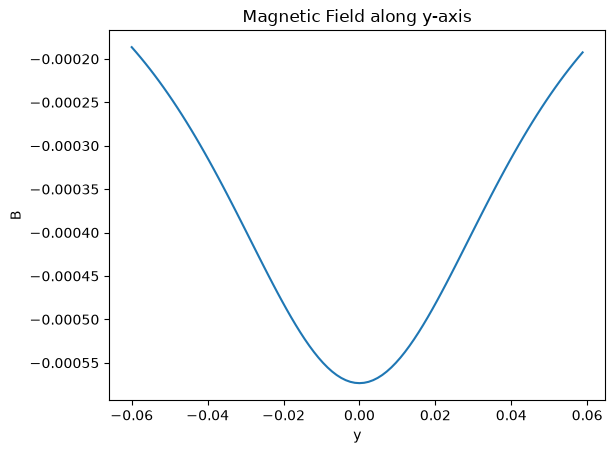

In [18]:
import matplotlib.pyplot as plt

arrayB = []
for i in range(0, 100):
    y = -0.06 + i * 0.0012 #y-sweep starting 6 cm back, goin ginto +y
    magnet1 = Magnet(half_length_cube, half_length_cube, half_length_cube, start_x, y, mag_diam/2 - half_length_cube)
    B = magnet1.calculateB()
    arrayB.append(B)

plt.plot([(-0.06 + i * 0.0012) for i in range(0, 100)], arrayB)
plt.xlabel('y')
plt.ylabel('B')
plt.title('Magnetic Field along y-axis')
plt.show()

## Generation of positions for all 10 magnets

In [19]:
array_mags_pos = [] #array containg all position arrays of all magnets
for i in range(0, mag_amt, 1):
    array_mags_pos.append([i*math.tan(math.radians(90-angle))*(s_cube + d_cu_cu), i * (s_cube + d_cu_cu)])

In [20]:
import numpy as np

# ==========================================================
# More precise finite-cylinder force calculation
# ==========================================================

# Cylinder geometry
r_cyl = mag_diam / 2
L_cyl = 0.004

# Magnetization of cylindrical magnet


# Numerical integration resolution
Nr = 8
Ntheta = 24
Nz = 4

# Small step for numerical derivative dB/dy
h = 0.0005


def create_cylinder_points(r_cyl, L_cyl, Nr, Ntheta, Nz):
    """
    Divide the cylindrical magnet into small volume elements.
    Returns x/y/z offsets and volume dV of each element.
    """

    rho_edges = np.linspace(0, r_cyl, Nr + 1)
    rho = 0.5 * (rho_edges[:-1] + rho_edges[1:])
    dr = rho_edges[1:] - rho_edges[:-1]

    theta = np.linspace(0, 2*np.pi, Ntheta, endpoint=False)
    dtheta = 2*np.pi / Ntheta

    z_edges = np.linspace(-L_cyl/2, L_cyl/2, Nz + 1)
    z = 0.5 * (z_edges[:-1] + z_edges[1:])
    dz = z_edges[1:] - z_edges[:-1]

    points = []

    for i, r in enumerate(rho):
        for th in theta:
            for k, z_off in enumerate(z):

                x_off = r * np.cos(th)
                y_off = r * np.sin(th)

                dV = r * dr[i] * dtheta * dz[k]

                points.append((x_off, y_off, z_off, dV))

    return points


cylinder_points = create_cylinder_points(
    r_cyl,
    L_cyl,
    Nr,
    Ntheta,
    Nz
)


def B_total(x, y, z):
    """
    Total Bz from all cube magnets at a particular point.
    """

    B = 0.0

    for magnet_x, magnet_y in array_mags_pos:

        magnet = Magnet(
            half_length_cube,
            half_length_cube,
            half_length_cube,

            x - magnet_x,
            y - magnet_y,

            z - half_length_cube
        )

        B += magnet.calculateB()

    return B


def finite_cylinder_force(y_center):
    """
    Calculate total Fy on the finite cylindrical magnet.

    Fy = integral M * (dBz/dy) dV

    dBz/dy is calculated using a five-point centred stencil.
    """

    F_total = 0.0

    for x_off, y_off, z_off, dV in cylinder_points:

        # Actual position of this cylinder volume element
        x = start_x + x_off
        y = y_center + y_off
        z = mag_diam / 2 + z_off

        # --------------------------------------------------
        # Five-point centred derivative
        # --------------------------------------------------

        B_minus_2h = B_total(
            x,
            y - 2 * h,
            z
        )

        B_minus_h = B_total(
            x,
            y - h,
            z
        )

        B_plus_h = B_total(
            x,
            y + h,
            z
        )

        B_plus_2h = B_total(
            x,
            y + 2 * h,
            z
        )

        dBdy_local = (
            B_minus_2h
            - 8 * B_minus_h
            + 8 * B_plus_h
            - B_plus_2h
        ) / (12 * h)

        # Force contribution from this volume element
        dF = (
            M_cyl
            * dBdy_local
            * dV
        )

        F_total += dF

    return F_total

## Plot of B_field of 10 magnets

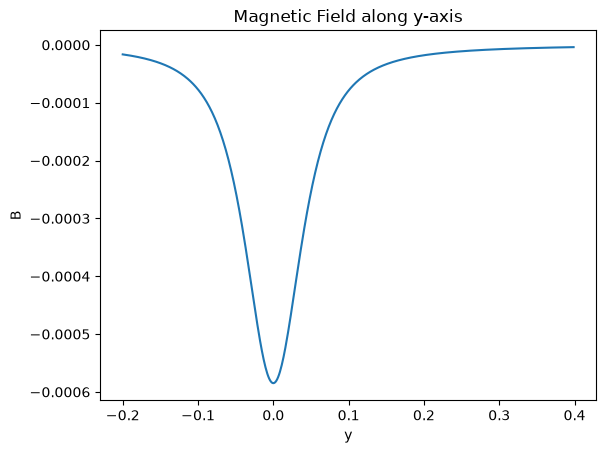

In [21]:
import matplotlib.pyplot as plt

arrayB = []
for i in range(0, 500):
    y = -0.2 + i * 0.0012 #y-sweep starting 6 cm back, going into +y
    B = 0
    for magnet_x, magnet_y in array_mags_pos:
        magnet = Magnet(half_length_cube, half_length_cube, half_length_cube, start_x - magnet_x, y - magnet_y, mag_diam/2 - half_length_cube)
        B += magnet.calculateB()
    arrayB.append(B)

array_y =[]
for i in range(0, 500):
    array_y.append((-0.2 + i * 0.0012))

plt.plot(array_y, arrayB)
plt.xlabel('y')
plt.ylabel('B')
plt.title('Magnetic Field along y-axis')
plt.show()

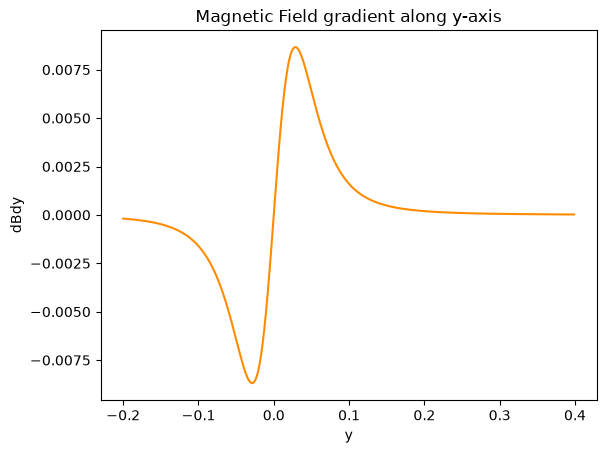

In [22]:
import numpy as np
dBdy = np.gradient(arrayB, array_y)

plt.plot(array_y, dBdy, color = "darkorange")
plt.xlabel('y')
plt.ylabel('dBdy')
plt.title('Magnetic Field gradient along y-axis')
plt.show()

## Acceleration function with parameter y

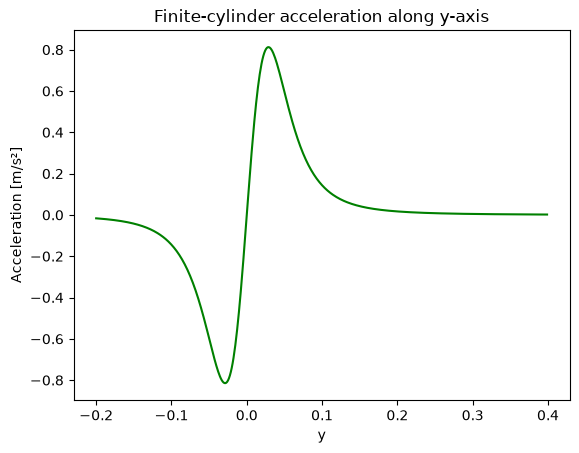

In [23]:
a_cyl = []

for y in array_y:
    Fy = finite_cylinder_force(y)

    # keep same plate correction as old model
    Fy = 2 * plate_factor * Fy

    acceleration = Fy / M_vehicle
    a_cyl.append(acceleration)

plt.plot(array_y, a_cyl, color="green")
plt.xlabel("y")
plt.ylabel("Acceleration [m/s²]")
plt.title("Finite-cylinder acceleration along y-axis")
plt.show()

## Making polynomial through interpolation

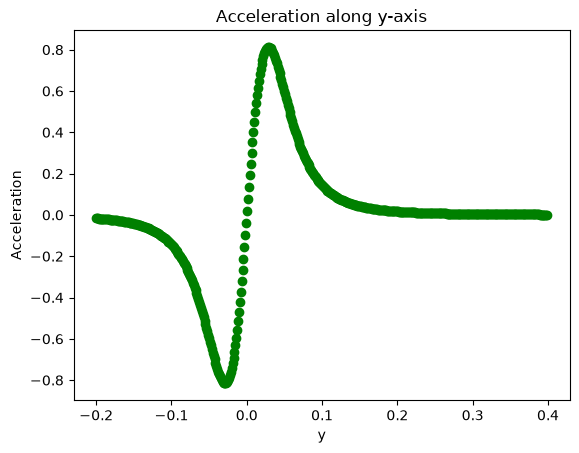

In [24]:
plt.plot(array_y, a_cyl, "o", color="green")
plt.xlabel("y")
plt.ylabel("Acceleration")
plt.title("Acceleration along y-axis")
plt.show()

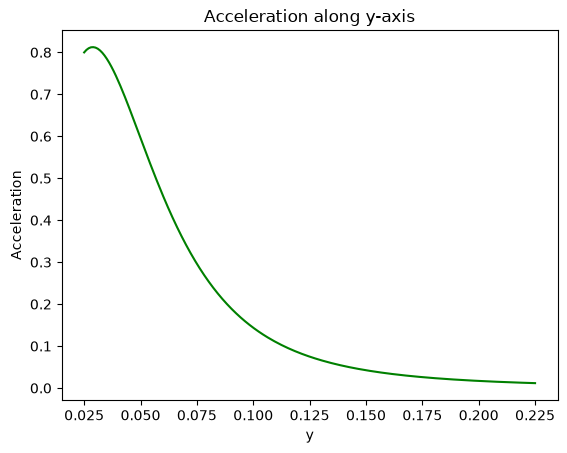

[0.79987794 0.80581236 0.80983075 0.81204789 0.81242965 0.81136119
 0.80869581 0.80457361 0.79912105 0.79244108 0.78464476 0.77584233
 0.7661236  0.75558003 0.74430189 0.73237672 0.71989016 0.70692694
 0.69355991 0.6798578  0.66588546 0.65170363 0.63736924 0.62293729
 0.60845507 0.59396542 0.57950752 0.56511694 0.55082589 0.53666474
 0.52265909 0.50883102 0.49519996 0.48178283 0.46859425 0.45564754
 0.44295333 0.43051984 0.41835367 0.40645991 0.39484227 0.38350374
 0.37244603 0.36166928 0.35117279 0.34095505 0.3310139  0.32134678
 0.31195076 0.30282192 0.29395597 0.2853483  0.27699403 0.26888816
 0.26102572 0.25340121 0.24600901 0.23884342 0.2318987  0.22516916
 0.21864931 0.21233339 0.20621566 0.20029043 0.1945521  0.18899515
 0.18361432 0.1784043  0.17335978 0.16847562 0.16374675 0.15916826
 0.15473546 0.15044371 0.1462884  0.14226509 0.13836943 0.13459721
 0.13094443 0.12740716 0.12398156 0.12066386 0.11745045 0.11433782
 0.11132263 0.10840163 0.10557166 0.10282961 0.10017252 0.0975

In [25]:
from scipy.interpolate import PchipInterpolator

P = PchipInterpolator(array_y, a_cyl)


y_plot = np.linspace(rolling_start_y, rolling_end_y, 200)

plt.plot(y_plot, P(y_plot), color="green")
plt.xlabel("y")
plt.ylabel("Acceleration")
plt.title("Acceleration along y-axis")
plt.show()

print(P(y_plot))

Cube magnetisation = 1.039282e+06 A/m
Cylinder magnetisation = 9.668663e+05 A/m
Effective mass = 0.09825 kg

Integrated theoretical acceleration:
0.6 cm: 0.6656 m/s²
1.1 cm: 0.6236 m/s²
1.2 cm: 0.6129 m/s²
1.6 cm: 0.5665 m/s²
2.1 cm: 0.5065 m/s²
2.6 cm: 0.4488 m/s²
3.1 cm: 0.3935 m/s²
3.6 cm: 0.3378 m/s²

30 mN acceleration offset = 0.3053 m/s²


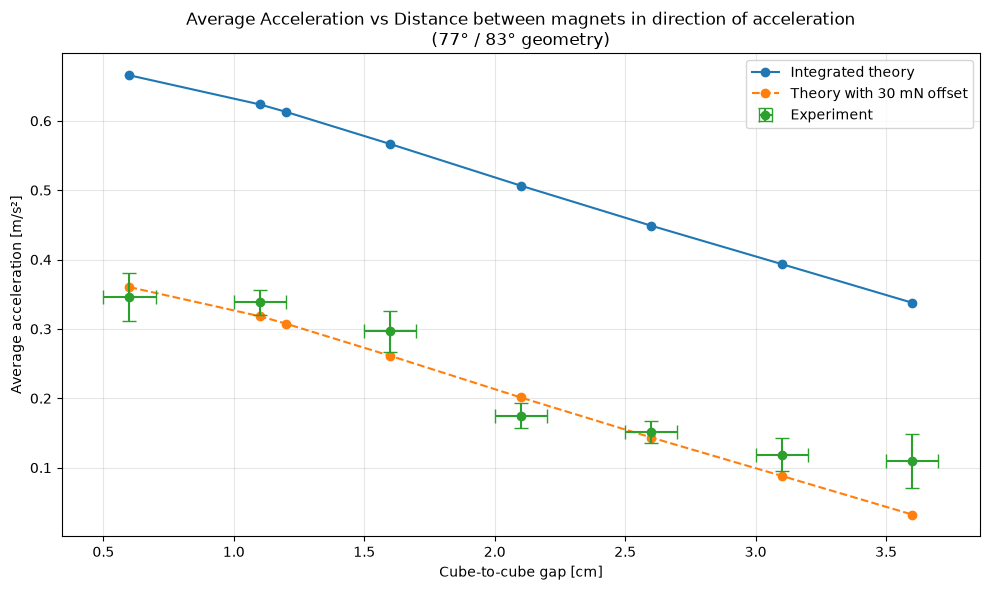

In [26]:
# ==========================================================
# FINAL DISTANCE-SWEEP MODEL
# Explicit 77° and 83° sides + rotational effective mass
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Magnetic properties
# ----------------------------------------------------------

mu0 = 4 * np.pi * 1e-7

# Existing notebook remanence values
Br_cube = 1.306   # T
Br_cyl = 1.215    # T

# Magnetisation derived from remanence: M = Br / mu0
M_cube = Br_cube / mu0
M_cyl = Br_cyl / mu0

print(f"Cube magnetisation = {M_cube:.6e} A/m")
print(f"Cylinder magnetisation = {M_cyl:.6e} A/m")

# ----------------------------------------------------------
# 2. Geometry and mass
# ----------------------------------------------------------

cube_half_length = 0.005  # m

r_cyl = 0.0175            # m
L_cyl = 0.004             # m

number_of_magnets = 4

plate_angle_77 = 77.0
plate_angle_83 = 83.0

# Measured cylinder positions relative to the first cube
x_fixed_77 = +0.0560   # m
x_fixed_83 = -0.0507   # m

z_cylinder = 0.0175    # m

plate_factor = 1.14

# Physical vehicle mass
vehicle_mass = 0.07125  # kg

# One rolling cylindrical magnet
disc_mass = 0.027       # kg

# Two solid cylinders:
# 2(I/r²) = 2(1/2 m) = one disc mass
rotational_mass_equivalent = (
    2 * 0.5 * disc_mass
)

effective_mass = (
    vehicle_mass
    + rotational_mass_equivalent
)

print(f"Effective mass = {effective_mass:.5f} kg")

# ----------------------------------------------------------
# 3. Field of one cube magnet
# ----------------------------------------------------------

def field_helper(x, y, z, a, b, c):

    distance = np.sqrt(
        (x + a)**2
        + (y + b)**2
        + (z + c)**2
    )

    return np.arctan2(
        (x + a) * (y + b),
        (z + c) * distance + 1e-15
    )


def Bz_cube(x, y, z):

    a = b = c = cube_half_length

    field_sum = (
        field_helper(-x,  y,  z, a, b, c)
        + field_helper(-x,  y, -z, a, b, c)
        + field_helper(-x, -y,  z, a, b, c)
        + field_helper(-x, -y, -z, a, b, c)
        + field_helper( x,  y,  z, a, b, c)
        + field_helper( x,  y, -z, a, b, c)
        + field_helper( x, -y,  z, a, b, c)
        + field_helper( x, -y, -z, a, b, c)
    )

    return (
        -(mu0 * M_cube / (4 * np.pi))
        * field_sum
    )


# ----------------------------------------------------------
# 4. Cylinder volume integration points
# ----------------------------------------------------------

def create_cylinder_points(
    radius,
    length,
    Nr=8,
    Ntheta=20,
    Nz=4
):

    rho_edges = np.linspace(
        0.0,
        radius,
        Nr + 1
    )

    rho = 0.5 * (
        rho_edges[:-1]
        + rho_edges[1:]
    )

    dr = (
        rho_edges[1:]
        - rho_edges[:-1]
    )

    theta = np.linspace(
        0.0,
        2 * np.pi,
        Ntheta,
        endpoint=False
    )

    dtheta = 2 * np.pi / Ntheta

    z_edges = np.linspace(
        -length / 2,
        length / 2,
        Nz + 1
    )

    z_points = 0.5 * (
        z_edges[:-1]
        + z_edges[1:]
    )

    dz = (
        z_edges[1:]
        - z_edges[:-1]
    )

    RHO, THETA, Z = np.meshgrid(
        rho,
        theta,
        z_points,
        indexing="ij"
    )

    DR, DTHETA, DZ = np.meshgrid(
        dr,
        np.full_like(theta, dtheta),
        dz,
        indexing="ij"
    )

    # Radial direction in the plane of the disc
    y_offsets = (
        RHO * np.cos(THETA)
    ).ravel()

    z_offsets = Z.ravel()

    volume_elements = (
        RHO
        * DR
        * DTHETA
        * DZ
    ).ravel()

    return (
        y_offsets,
        z_offsets,
        volume_elements
    )


y_offsets, z_offsets, volume_elements = (
    create_cylinder_points(
        r_cyl,
        L_cyl,
        Nr=8,
        Ntheta=20,
        Nz=4
    )
)

# ----------------------------------------------------------
# 5. Field from one side of the trapezoid
# ----------------------------------------------------------

def Bz_from_one_side(
    x_position,
    y_positions,
    z_positions,
    step_x,
    step_y
):

    total_field = np.zeros_like(
        y_positions,
        dtype=float
    )

    for magnet_number in range(
        number_of_magnets
    ):

        relative_x = (
            x_position
            - magnet_number * step_x
        )

        relative_y = (
            y_positions
            - magnet_number * step_y
        )

        total_field += Bz_cube(
            relative_x,
            relative_y,
            z_positions
        )

    return total_field


# ----------------------------------------------------------
# 6. Force on one cylinder from one side
# ----------------------------------------------------------

derivative_step = 5e-4  # m


def force_from_one_side(
    x_cylinder,
    y_cylinder,
    step_x,
    step_y
):

    y_volume_points = (
        y_cylinder
        + y_offsets
    )

    z_volume_points = (
        z_cylinder
        + z_offsets
    )

    # ------------------------------------------------------
    # Five-point centred derivative
    # ------------------------------------------------------

    B_minus_2h = Bz_from_one_side(
        x_cylinder,
        y_volume_points - 2 * derivative_step,
        z_volume_points,
        step_x,
        step_y
    )

    B_minus_h = Bz_from_one_side(
        x_cylinder,
        y_volume_points - derivative_step,
        z_volume_points,
        step_x,
        step_y
    )

    B_plus_h = Bz_from_one_side(
        x_cylinder,
        y_volume_points + derivative_step,
        z_volume_points,
        step_x,
        step_y
    )

    B_plus_2h = Bz_from_one_side(
        x_cylinder,
        y_volume_points + 2 * derivative_step,
        z_volume_points,
        step_x,
        step_y
    )

    dBdy = (
        B_minus_2h
        - 8 * B_minus_h
        + 8 * B_plus_h
        - B_plus_2h
    ) / (12 * derivative_step)

    force = np.sum(
        M_cyl
        * dBdy
        * volume_elements
    )

    return plate_factor * force

# ----------------------------------------------------------
# 7. Acceleration from both sides
# ----------------------------------------------------------

def acceleration_both_sides(
    y_position,
    cube_gap_m
):

    # Centre-to-centre distance between consecutive cubes
    step_y = (
        0.010
        + cube_gap_m
    )

    step_x_77 = (
        np.tan(
            np.deg2rad(
                90.0 - plate_angle_77
            )
        )
        * step_y
    )

    step_x_83 = (
        np.tan(
            np.deg2rad(
                90.0 - plate_angle_83
            )
        )
        * step_y
    )

    # Calculate the two sides independently
    force_77 = force_from_one_side(
        x_fixed_77,
        y_position,
        step_x_77,
        step_y
    )

    force_83 = force_from_one_side(
        x_fixed_83,
        y_position,
        step_x_83,
        step_y
    )

    total_force = (
        force_77
        + force_83
    )

    return total_force / effective_mass


# ----------------------------------------------------------
# 8. Spatial integration from 0.025 to 0.220 m
# ----------------------------------------------------------

integration_start = 0.025
integration_end = 0.220

y_integration = np.linspace(
    integration_start,
    integration_end,
    250
)


def integrated_average_acceleration(
    cube_gap_m
):

    acceleration_path = np.array([
        acceleration_both_sides(
            y,
            cube_gap_m
        )
        for y in y_integration
    ])

    return (
        np.trapezoid(
            acceleration_path,
            y_integration
        )
        /
        (
            integration_end
            - integration_start
        )
    )


# ----------------------------------------------------------
# 9. Distance sweep
# ----------------------------------------------------------

spacing_cm = np.array([
    0.6,
    1.1,
    1.2,
    1.6,
    2.1,
    2.6,
    3.1,
    3.6
])

theory = np.array([
    integrated_average_acceleration(
        distance_cm / 100.0
    )
    for distance_cm in spacing_cm
])

print("\nIntegrated theoretical acceleration:")

for distance, acceleration in zip(
    spacing_cm,
    theory
):
    print(
        f"{distance:.1f} cm: "
        f"{acceleration:.4f} m/s²"
    )


# ----------------------------------------------------------
# 10. Experimental data
# No experimental value exists at 1.2 cm
# ----------------------------------------------------------

experimental_spacing_cm = np.array([
    0.6,
    1.1,
    1.6,
    2.1,
    2.6,
    3.1,
    3.6
])

experimental_acceleration = np.array([
    0.3463595,
    0.3384158,
    0.2969192,
    0.1749574,
    0.1515178,
    0.1187936,
    0.1092068
])

experimental_error = np.array([
    0.03480550,
    0.01787546,
    0.02957192,
    0.01762536,
    0.01574086,
    0.02326507,
    0.03868291
])

# ----------------------------------------------------------
# 11. Residual-force offset
# ----------------------------------------------------------

residual_force = 0.030  # N = 30 mN

acceleration_offset = (
    residual_force
    / effective_mass
)

theory_with_offset = (
    theory
    - acceleration_offset
)

print(
    f"\n30 mN acceleration offset = "
    f"{acceleration_offset:.4f} m/s²"
)

# ----------------------------------------------------------
# 12. Final graph
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    spacing_cm,
    theory,
    "o-",
    color="tab:blue",
    label="Integrated theory"
)

plt.plot(
    spacing_cm,
    theory_with_offset,
    "o--",
    color="tab:orange",
    label="Theory with 30 mN offset"
)

plt.errorbar(
    experimental_spacing_cm,
    experimental_acceleration,
    xerr=0.1,
    yerr=experimental_error,
    fmt="o",
    color="tab:green",
    capsize=5,
    label="Experiment"
)

plt.xlabel(
    "Cube-to-cube gap [cm]"
)

plt.ylabel(
    "Average acceleration [m/s²]"
)

plt.title(
    "Average Acceleration vs Distance between magnets in direction of acceleration\n"
    "(77° / 83° geometry)"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

N = 1: 0.1452 m/s²
N = 2: 0.3270 m/s²
N = 3: 0.4964 m/s²
N = 4: 0.6129 m/s²
N = 5: 0.6740 m/s²
N = 6: 0.6938 m/s²
N = 7: 0.6785 m/s²
N = 8: 0.6180 m/s²

30 mN acceleration offset = 0.3053 m/s²


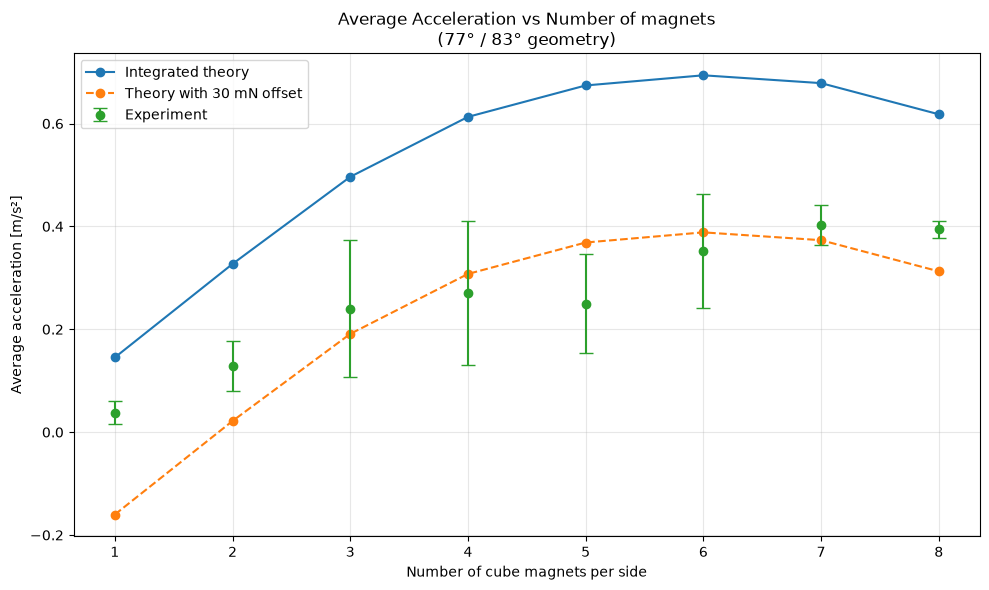

In [27]:
# ==========================================================
# SWEEP OVER NUMBER OF MAGNETS: 1 TO 8
# ==========================================================

# Experimental results
experimental_N = np.array([
    1, 2, 3, 4, 5, 6, 7, 8
])

experimental_a_N = np.array([
    0.037808556,
    0.128455951,
    0.240304910,
    0.270992627,
    0.250021209,
    0.351838259,
    0.402998000,
    0.394077600
])

experimental_err_N = np.array([
    0.022652615,
    0.048540607,
    0.133972652,
    0.140193251,
    0.096880147,
    0.111238021,
    0.038761895,
    0.017363004
])

# Number of magnets to test
magnet_numbers = np.arange(1, 9)

# Fixed cube-to-cube gap used in this experiment
fixed_cube_gap = 0.012  # m = 1.2 cm

# Save the original value
original_number_of_magnets = number_of_magnets

theory_N = []

# Calculate the integrated theory for 1–8 magnets
for N in magnet_numbers:

    number_of_magnets = N

    average_acceleration_N = (
        integrated_average_acceleration(
            fixed_cube_gap
        )
    )

    theory_N.append(
        average_acceleration_N
    )

    print(
        f"N = {N}: "
        f"{average_acceleration_N:.4f} m/s²"
    )

# Convert to NumPy array
theory_N = np.array(theory_N)

# Restore the original value
number_of_magnets = original_number_of_magnets

# ----------------------------------------------------------
# Residual-force offset for the magnet-number sweep
# ----------------------------------------------------------

residual_force_N = 0.030  # N = 30 mN

acceleration_offset_N = (
    residual_force_N
    / effective_mass
)

theory_with_offset_N = (
    theory_N
    - acceleration_offset_N
)

print(
    f"\n30 mN acceleration offset = "
    f"{acceleration_offset_N:.4f} m/s²"
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    magnet_numbers,
    theory_N,
    "o-",
    color="tab:blue",
    label="Integrated theory"
)

plt.plot(
    magnet_numbers,
    theory_with_offset_N,
    "o--",
    color="tab:orange",
    label="Theory with 30 mN offset"
)

plt.errorbar(
    experimental_N,
    experimental_a_N,
    yerr=experimental_err_N,
    fmt="o",
    color="tab:green",
    capsize=5,
    label="Experiment"
)

plt.xlabel(
    "Number of cube magnets per side"
)

plt.ylabel(
    "Average acceleration [m/s²]"
)

plt.title(
    "Average Acceleration vs Number of magnets\n"
    "(77° / 83° geometry)"
)

plt.xticks(magnet_numbers)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

83° cylinder-to-magnet x-positions:
Edge distance =  5 mm -> x83 = -0.0407 m
Edge distance =  7 mm -> x83 = -0.0427 m
Edge distance =  9 mm -> x83 = -0.0447 m
Edge distance = 11 mm -> x83 = -0.0467 m
Edge distance = 13 mm -> x83 = -0.0487 m
Edge distance = 15 mm -> x83 = -0.0507 m
Edge distance = 17 mm -> x83 = -0.0527 m



Integrated theoretical results:
 5 mm: 0.7389 m/s²
 7 mm: 0.7138 m/s²
 9 mm: 0.6895 m/s²
11 mm: 0.6663 m/s²
13 mm: 0.6443 m/s²
15 mm: 0.6236 m/s²
17 mm: 0.6043 m/s²

25 mN acceleration offset = 0.2545 m/s²


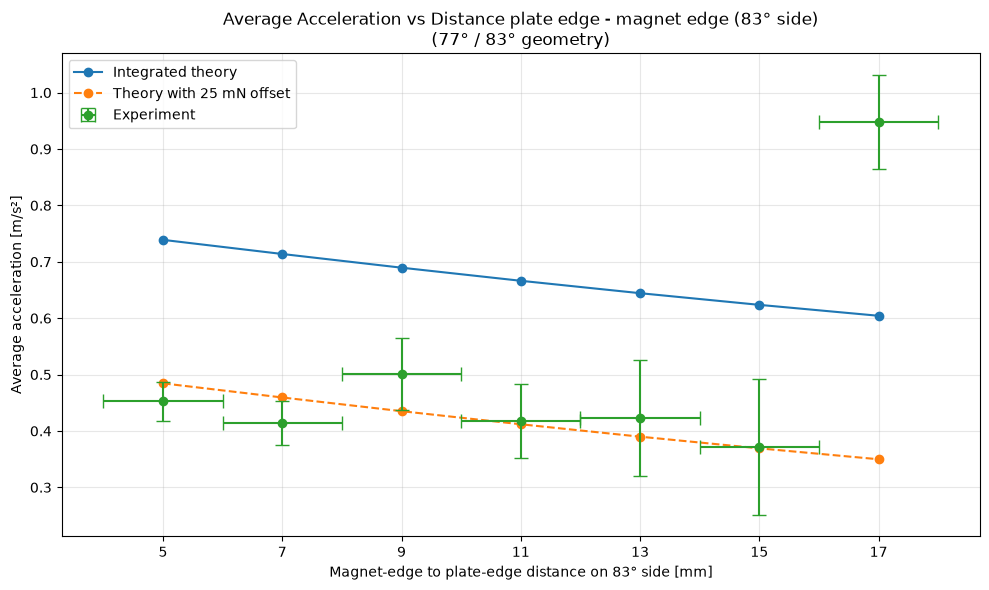

In [28]:
# ==========================================================
# SWEEP: MAGNET-TO-PLATE-EDGE DISTANCE ON THE 83° SIDE
# ==========================================================

# Experimental magnet-edge to plate-edge distances
edge_distances_mm = np.array([
    5, 7, 9, 11, 13, 15, 17
])

experimental_a_edge = np.array([
    0.45246700,
    0.41439420,
    0.50117267,
    0.41778733,
    0.42268300,
    0.37151800,
    0.94796775
])

experimental_err_edge = np.array([
    0.03411016,
    0.03949804,
    0.06351325,
    0.06629884,
    0.10278590,
    0.11973754,
    0.08273723
])

# ----------------------------------------------------------
# Fixed experimental parameters
# ----------------------------------------------------------

fixed_cube_gap_edge = 0.011  # m = 1.1 cm
fixed_number_of_magnets = 4

# Measured reference:
# 15 mm edge distance corresponds to x83 = -0.0507 m
reference_edge_distance = 0.015  # m
reference_x_83 = -0.0507         # m

# Save the previous magnet-number setting
original_number_of_magnets = number_of_magnets
number_of_magnets = fixed_number_of_magnets

# ----------------------------------------------------------
# Convert plate-edge distance into the 83° x-position
# ----------------------------------------------------------

def x83_from_edge_distance(edge_distance_m):
    """
    Increasing the magnet-to-edge distance increases the
    distance between the 83° cylinder and the magnets.

    Calibrated using:
        edge distance = 15 mm
        x83 = -0.0507 m
    """

    return (
        reference_x_83
        -
        (
            edge_distance_m
            - reference_edge_distance
        )
    )


# Show the x-positions used
print("83° cylinder-to-magnet x-positions:")

for edge_mm in edge_distances_mm:

    x83_value = x83_from_edge_distance(
        edge_mm / 1000.0
    )

    print(
        f"Edge distance = {edge_mm:2d} mm "
        f"-> x83 = {x83_value:.4f} m"
    )

# ----------------------------------------------------------
# Acceleration for a selected plate-edge distance
# ----------------------------------------------------------

def acceleration_for_edge_distance(
    y_position,
    edge_distance_m
):

    step_y = (
        0.010
        + fixed_cube_gap_edge
    )

    step_x_77 = (
        np.tan(
            np.deg2rad(
                90.0 - plate_angle_77
            )
        )
        * step_y
    )

    step_x_83 = (
        np.tan(
            np.deg2rad(
                90.0 - plate_angle_83
            )
        )
        * step_y
    )

    # 77° side remains unchanged
    force_77 = force_from_one_side(
        x_fixed_77,
        y_position,
        step_x_77,
        step_y
    )

    # Only the 83° side position changes
    current_x_83 = x83_from_edge_distance(
        edge_distance_m
    )

    force_83 = force_from_one_side(
        current_x_83,
        y_position,
        step_x_83,
        step_y
    )

    total_force = (
        force_77
        + force_83
    )

    return total_force / effective_mass


# ----------------------------------------------------------
# Integrate over 0.025–0.220 m
# ----------------------------------------------------------

def integrated_edge_acceleration(
    edge_distance_m
):

    acceleration_path = np.array([
        acceleration_for_edge_distance(
            y,
            edge_distance_m
        )
        for y in y_integration
    ])

    return (
        np.trapezoid(
            acceleration_path,
            y_integration
        )
        /
        (
            integration_end
            - integration_start
        )
    )


# ----------------------------------------------------------
# Calculate the theoretical sweep
# ----------------------------------------------------------

theory_edge = np.array([
    integrated_edge_acceleration(
        edge_mm / 1000.0
    )
    for edge_mm in edge_distances_mm
])

# Restore previous global magnet-number setting
number_of_magnets = original_number_of_magnets

print("\nIntegrated theoretical results:")

for edge_mm, acceleration in zip(
    edge_distances_mm,
    theory_edge
):

    print(
        f"{edge_mm:2d} mm: "
        f"{acceleration:.4f} m/s²"
    )

# ----------------------------------------------------------
# Residual-force offset
# ----------------------------------------------------------

residual_force_edge = 0.025  # N = 25 mN

acceleration_offset_edge = (
    residual_force_edge
    / effective_mass
)

theory_with_offset_edge = (
    theory_edge
    - acceleration_offset_edge
)

print(
    f"\n25 mN acceleration offset = "
    f"{acceleration_offset_edge:.4f} m/s²"
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    edge_distances_mm,
    theory_edge,
    "o-",
    color="tab:blue",
    label="Integrated theory"
)

plt.plot(
    edge_distances_mm,
    theory_with_offset_edge,
    "o--",
    color="tab:orange",
    label="Theory with 25 mN offset"
)

plt.errorbar(
    edge_distances_mm,
    experimental_a_edge,
    xerr=1,
    yerr=experimental_err_edge,
    fmt="o",
    color="tab:green",
    capsize=5,
    label="Experiment"
)

plt.xlabel(
    "Magnet-edge to plate-edge distance on 83° side [mm]"
)

plt.ylabel(
    "Average acceleration [m/s²]"
)

plt.title(
    "Average Acceleration vs Distance plate edge - magnet edge (83° side)\n"
    "(77° / 83° geometry)"
)

plt.xticks(edge_distances_mm)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Integrated theoretical angle results:
Angle = 75.0°: 0.7160 m/s²
Angle = 77.0°: 0.7023 m/s²
Angle = 80.0°: 0.6831 m/s²
Angle = 83.0°: 0.6653 m/s²

51 mN acceleration offset = 0.5191 m/s²


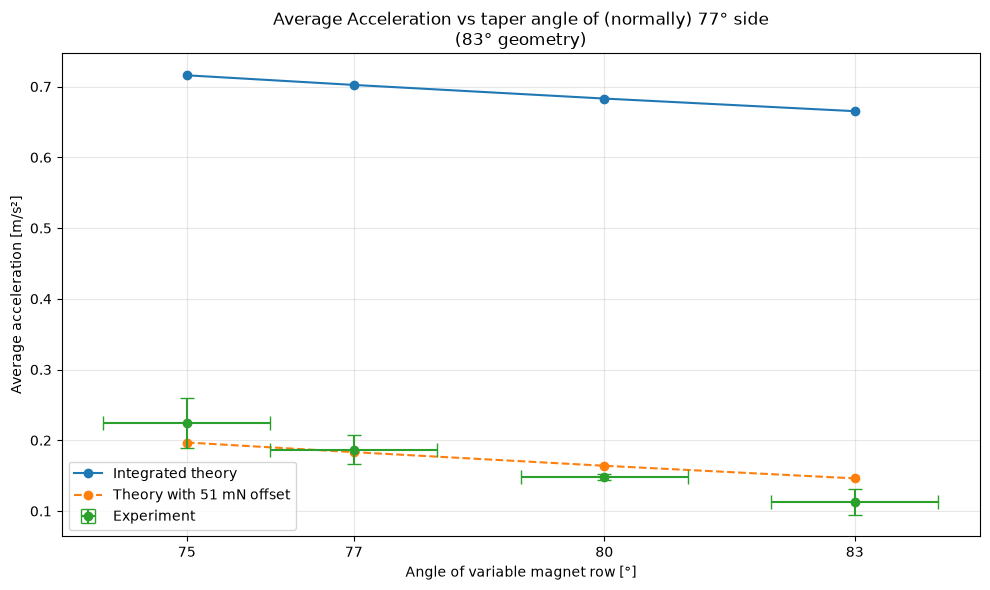

In [29]:
# ==========================================================
# SWEEP: VARIABLE PLATE ANGLE
# Normally 77° side varied; 83° side fixed
# ==========================================================

experimental_angles = np.array([
    75.0,
    77.0,
    80.0,
    83.0
])

experimental_a_angle = np.array([
    0.2245326,
    0.1868504,
    0.1486434,
    0.1128628
])

experimental_err_angle = np.array([
    0.0352,
    0.0201,
    0.0041,
    0.0178
])

experimental_angle_err = 1.0

# ----------------------------------------------------------
# Fixed experimental parameters
# ----------------------------------------------------------

fixed_cube_gap_angle = 0.011  # m = 1.1 cm
fixed_number_of_magnets_angle = 4

# Variable, normally 77° side: positive-x side
x_variable_row = +0.0560  # m

# Fixed 83° side: negative-x side
x_fixed_row = -0.0507  # m
fixed_row_angle = 83.0

# Save the previous global value
original_number_of_magnets = number_of_magnets
number_of_magnets = fixed_number_of_magnets_angle

# ----------------------------------------------------------
# Acceleration for one variable angle
# ----------------------------------------------------------

def acceleration_for_variable_angle(
    y_position,
    variable_angle_deg
):

    # Centre-to-centre y-distance
    step_y = (
        0.010
        + fixed_cube_gap_angle
    )

    # Variable row lies on the positive-x side
    step_x_variable = (
        np.tan(
            np.deg2rad(
                90.0 - variable_angle_deg
            )
        )
        * step_y
    )

    # Fixed row lies on the negative-x side.
    # Therefore, the x-step must have a negative sign.
    step_x_fixed = -(
        np.tan(
            np.deg2rad(
                90.0 - fixed_row_angle
            )
        )
        * step_y
    )

    # Variable, normally 77° row
    force_variable = force_from_one_side(
        x_variable_row,
        y_position,
        step_x_variable,
        step_y
    )

    # Fixed 83° row
    force_fixed = force_from_one_side(
        x_fixed_row,
        y_position,
        step_x_fixed,
        step_y
    )

    total_force = (
        force_variable
        + force_fixed
    )

    return total_force / effective_mass


# ----------------------------------------------------------
# Integrate over 0.025–0.220 m
# ----------------------------------------------------------

def integrated_angle_acceleration(
    variable_angle_deg
):

    acceleration_path = np.array([
        acceleration_for_variable_angle(
            y,
            variable_angle_deg
        )
        for y in y_integration
    ])

    return (
        np.trapezoid(
            acceleration_path,
            y_integration
        )
        /
        (
            integration_end
            - integration_start
        )
    )


# ----------------------------------------------------------
# Calculate theoretical results
# ----------------------------------------------------------

theory_angle = np.array([
    integrated_angle_acceleration(angle)
    for angle in experimental_angles
])

# Restore the previous setting
number_of_magnets = original_number_of_magnets

print("Integrated theoretical angle results:")

for angle, acceleration in zip(
    experimental_angles,
    theory_angle
):

    print(
        f"Angle = {angle:.1f}°: "
        f"{acceleration:.4f} m/s²"
    )

# ----------------------------------------------------------
# Residual-force offset
# ----------------------------------------------------------

residual_force_angle = 0.051  # N = 51 mN

acceleration_offset_angle = (
    residual_force_angle
    / effective_mass
)

theory_with_offset_angle = (
    theory_angle
    - acceleration_offset_angle
)

print(
    f"\n51 mN acceleration offset = "
    f"{acceleration_offset_angle:.4f} m/s²"
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    experimental_angles,
    theory_angle,
    "o-",
    color="tab:blue",
    label="Integrated theory"
)

plt.plot(
    experimental_angles,
    theory_with_offset_angle,
    "o--",
    color="tab:orange",
    label="Theory with 51 mN offset"
)

plt.errorbar(
    experimental_angles,
    experimental_a_angle,
    xerr=experimental_angle_err,
    yerr=experimental_err_angle,
    fmt="o",
    color="tab:green",
    capsize=5,
    label="Experiment"
)

plt.xlabel(
    "Angle of variable magnet row [°]"
)

plt.ylabel(
    "Average acceleration [m/s²]"
)

plt.title(
    "Average Acceleration vs taper angle of (normally) 77° side\n"
    "(83° geometry)"
)

plt.xticks(experimental_angles)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()